In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [19]:
df = pd.read_csv('../dataset/majorproject_df.csv')

In [20]:
wind_df = df[[
    'datetime',
    'temp_C',
    'humidity_%',
    'wind_speed_m_s',
    'precip_mm',
    'installed_wind_MW',
    'weather',
    'wind_gen_MW'
]]

In [21]:
wind_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52608 entries, 0 to 52607
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   datetime           52608 non-null  object 
 1   temp_C             52608 non-null  float64
 2   humidity_%         52608 non-null  float64
 3   wind_speed_m_s     52608 non-null  float64
 4   precip_mm          52608 non-null  float64
 5   installed_wind_MW  52608 non-null  float64
 6   weather            52608 non-null  object 
 7   wind_gen_MW        52608 non-null  float64
dtypes: float64(6), object(2)
memory usage: 3.2+ MB


In [22]:
wind_df['datetime'] = pd.to_datetime(wind_df['datetime'])


wind_df['year'] = wind_df['datetime'].dt.year
wind_df['month'] = wind_df['datetime'].dt.month
wind_df['day'] = wind_df['datetime'].dt.day
wind_df['hour'] = wind_df['datetime'].dt.hour
wind_df.head()

C:\Users\4Sahi\AppData\Local\Temp\ipykernel_26396\690131706.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wind_df['datetime'] = pd.to_datetime(wind_df['datetime'])
C:\Users\4Sahi\AppData\Local\Temp\ipykernel_26396\690131706.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wind_df['year'] = wind_df['datetime'].dt.year
C:\Users\4Sahi\AppData\Local\Temp\ipykernel_26396\690131706.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer

,datetime,temp_C,humidity_%,wind_speed_m_s,precip_mm,installed_wind_MW,weather,wind_gen_MW,year,month,day,hour
0,2019-01-01 00:00:00,26.33,78.3,5.80,0.0,8500.0,Cloudy,239.690,2019,1,1,0
1,2019-01-01 01:00:00,28.42,74.6,3.21,0.0,8500.0,Cloudy,0.097,2019,1,1,1
2,2019-01-01 02:00:00,26.14,84.8,4.82,0.0,8500.0,Cloudy,65.787,2019,1,1,2
3,2019-01-01 03:00:00,22.16,86.6,3.58,0.0,8500.0,Cloudy,2.170,2019,1,1,3
4,2019-01-01 04:00:00,22.26,74.0,3.04,0.0,8500.0,Cloudy,0.000,2019,1,1,4


In [23]:
wind_df = wind_df.drop(columns=['datetime'])

In [24]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)
weather_encoded = encoder.fit_transform(wind_df[['weather']])

weather_df = pd.DataFrame(weather_encoded, columns=encoder.get_feature_names_out(['weather']))

wind_df = pd.concat([wind_df.drop(columns=['weather']), weather_df], axis=1)

In [25]:
import pickle

with open("../models-encoders/wind-ohe.pickle", "wb") as file:
    pickle.dump(encoder, file)

In [26]:
wind_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52608 entries, 0 to 52607
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   temp_C             52608 non-null  float64
 1   humidity_%         52608 non-null  float64
 2   wind_speed_m_s     52608 non-null  float64
 3   precip_mm          52608 non-null  float64
 4   installed_wind_MW  52608 non-null  float64
 5   wind_gen_MW        52608 non-null  float64
 6   year               52608 non-null  int32  
 7   month              52608 non-null  int32  
 8   day                52608 non-null  int32  
 9   hour               52608 non-null  int32  
 10  weather_Cloudy     52608 non-null  float64
 11  weather_Rainy      52608 non-null  float64
 12  weather_Sunny      52608 non-null  float64
dtypes: float64(9), int32(4)
memory usage: 4.4 MB


In [27]:
wind_df.corr()['wind_gen_MW'].abs().sort_values(ascending=False)

wind_gen_MW          1.000000
wind_speed_m_s       0.801483
temp_C               0.603365
humidity_%           0.522239
month                0.330847
hour                 0.162850
weather_Rainy        0.137011
weather_Sunny        0.096649
year                 0.038553
installed_wind_MW    0.038553
weather_Cloudy       0.025631
day                  0.004712
precip_mm            0.003525
Name: wind_gen_MW, dtype: float64

In [28]:
X = wind_df.drop(columns=['wind_gen_MW'])
y = wind_df['wind_gen_MW']

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
import pickle

with open("../models-encoders/wind-encoder.pickle", "wb") as file:
    pickle.dump(scaler, file)

Best Model: Random Forest
R2 Score: 0.999758
MAE: 1.717810
RMSE: 10.577235


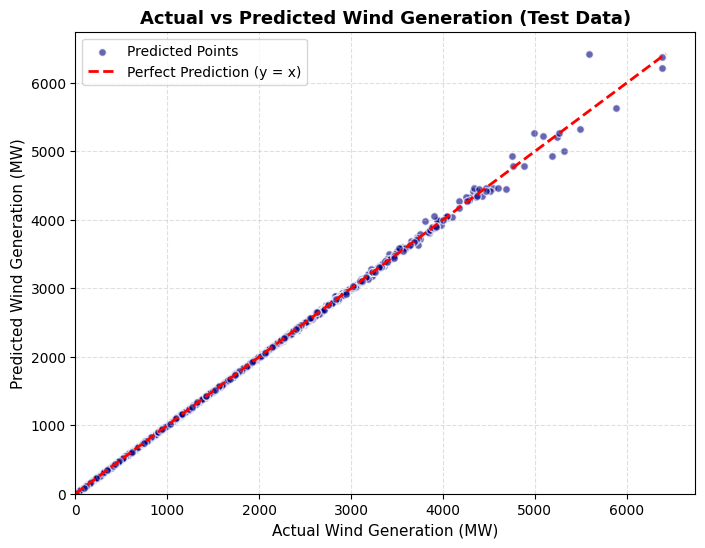

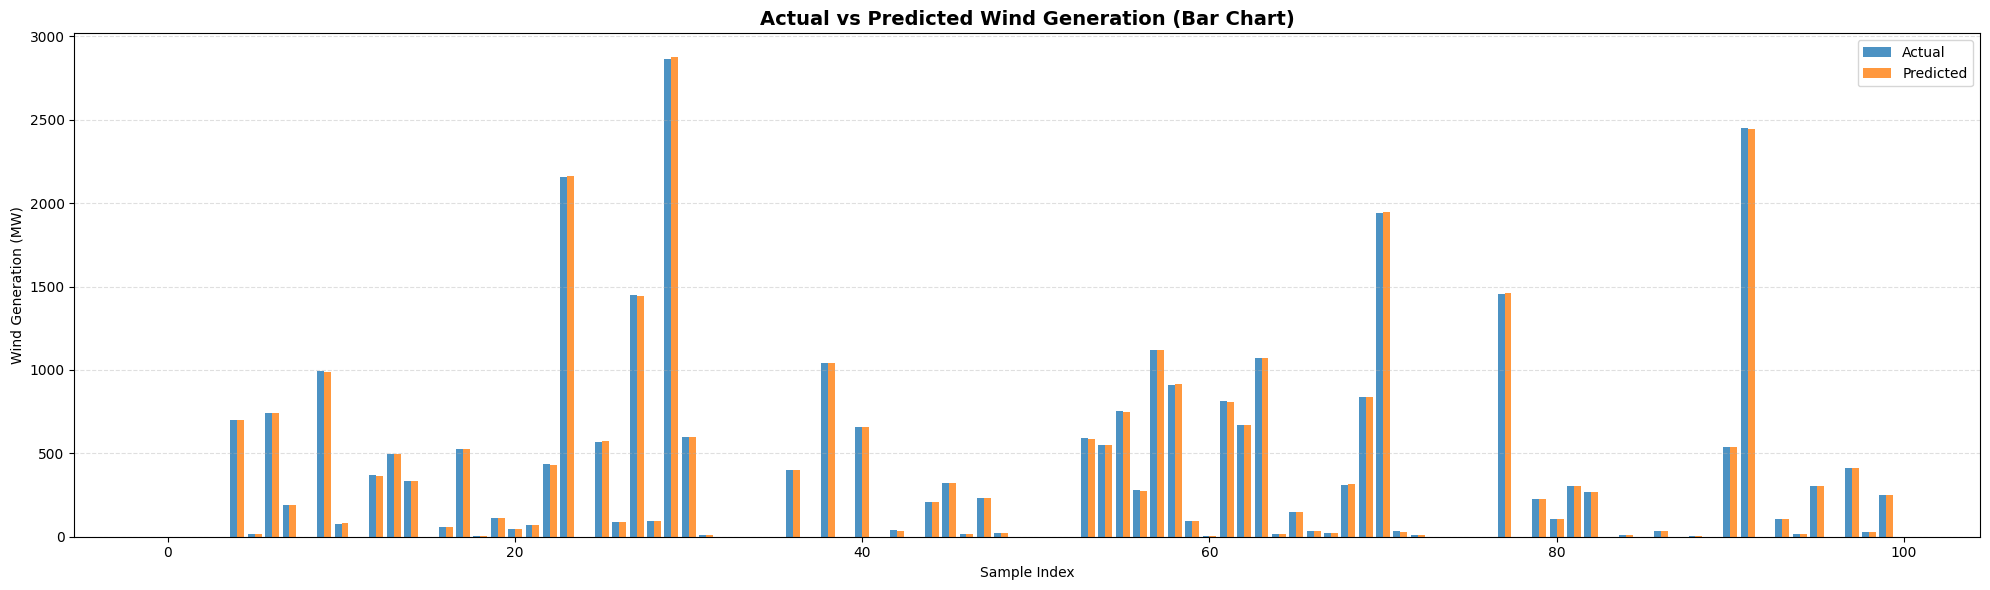

In [32]:
from sklearn.ensemble import RandomForestRegressor

best_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)


best_model.fit(X_train_scaled, y_train)
import pickle

with open("../models-encoders/wind-model.pickle", "wb") as file:
    pickle.dump(best_model, file)

# importances = best_model.feature_importances_
# feature_importance_df = pd.DataFrame({
#     'Feature': X_train.columns,
#     'Importance': importances
# }).sort_values(by='Importance', ascending=False)
y_pred_best = best_model.predict(X_test_scaled)


from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

r2 = r2_score(y_test, y_pred_best)
mae = mean_absolute_error(y_test, y_pred_best)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_best))

print(f"Best Model: Random Forest")
print(f"R2 Score: {r2:.6f}")
print(f"MAE: {mae:.6f}")
print(f"RMSE: {rmse:.6f}")

import matplotlib.pyplot as plt
import numpy as np

# Actual vs Predicted scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_best, color='navy', alpha=0.6, edgecolor='white', label='Predicted Points',s=30)

# Perfect prediction line
min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction (y = x)')

# Labels and title
plt.title("Actual vs Predicted Wind Generation (Test Data)", fontsize=13, fontweight='bold')
plt.xlabel("Actual Wind Generation (MW)", fontsize=11)
plt.ylabel("Predicted Wind Generation (MW)", fontsize=11)
plt.legend()

# Add subtle grid and tighter limits for visibility
plt.grid(True, linestyle='--', alpha=0.4)
plt.xlim(min_val * 0.95, max_val * 1.05)
plt.ylim(min_val * 0.95, max_val * 1.05)

N = 100
actual = y_test[:N]
predicted = y_pred_best[:N]

# Create bar positions
x = np.arange(N)
width = 0.4

plt.figure(figsize=(20, 6))

# Bars for actual values
plt.bar(x - width/2, actual, width, label='Actual', alpha=0.8)

# Bars for predicted values
plt.bar(x + width/2, predicted, width, label='Predicted', alpha=0.8)

plt.title("Actual vs Predicted Wind Generation (Bar Chart)", fontsize=14, fontweight='bold')
plt.xlabel("Sample Index")
plt.ylabel("Wind Generation (MW)")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

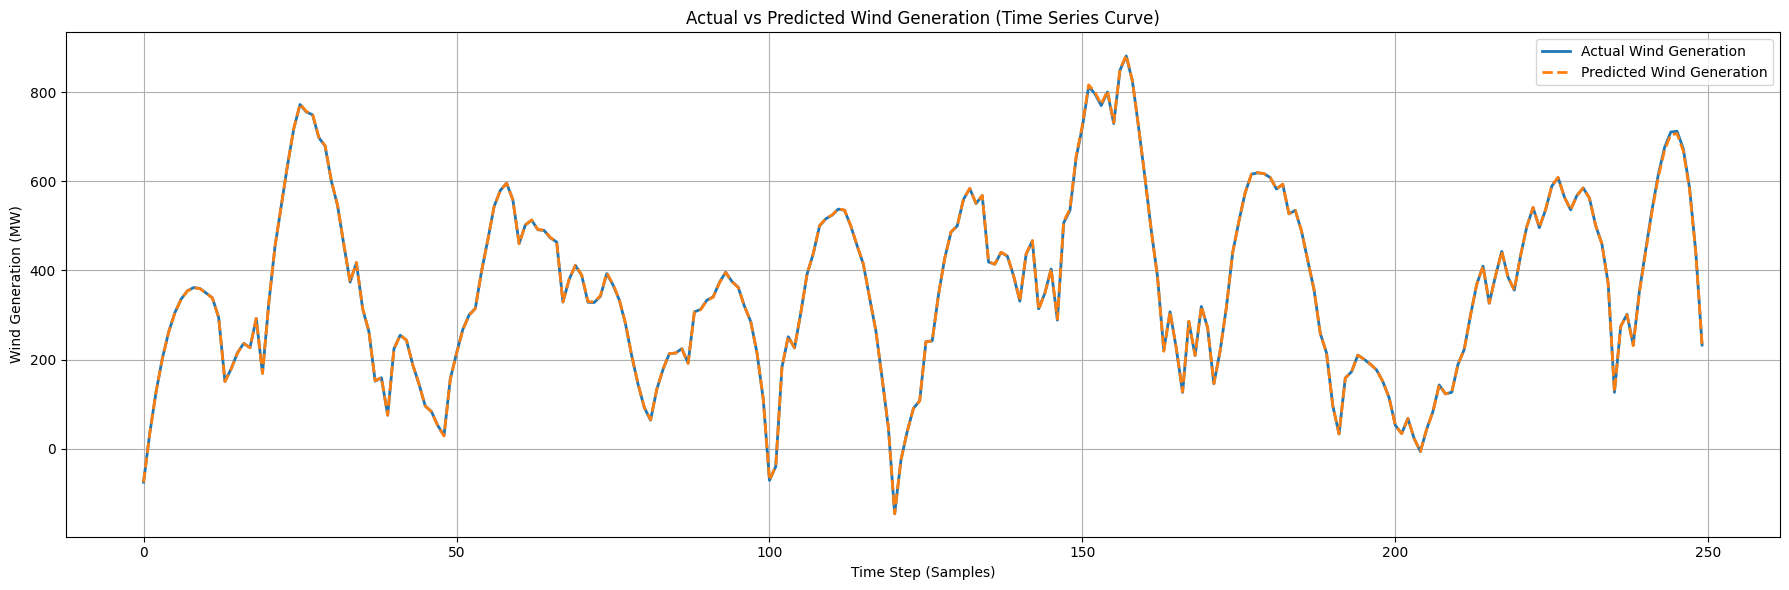

In [33]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import savgol_filter

# ------------------------------
# Select number of points to plot
# ------------------------------
N = 250   # you can increase if needed
actual = np.array(y_test[:N])
predicted = np.array(y_pred_best[:N])

# ------------------------------
# Optional smoothing
# ------------------------------
actual_smooth = savgol_filter(actual, window_length=21, polyorder=3)
pred_smooth = savgol_filter(predicted, window_length=21, polyorder=3)

# Time axis
time = np.arange(N)

# ------------------------------
# Plot curves
# ------------------------------
plt.figure(figsize=(18, 6))

plt.plot(time, actual_smooth, label='Actual Wind Generation', linewidth=2)
plt.plot(time, pred_smooth, label='Predicted Wind Generation', linestyle='--', linewidth=2)

plt.title("Actual vs Predicted Wind Generation (Time Series Curve)")
plt.xlabel("Time Step (Samples)")
plt.ylabel("Wind Generation (MW)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
